In [1]:
import os
import cv2
from tqdm import tqdm
from pathlib import Path

In [2]:
DATASET_DIR = Path("../Dataset/Real-life_Deception_Detection_2016")
CLIPS_DIR = DATASET_DIR / "Clips"

DECEPTIVE_DIR = CLIPS_DIR / "Deceptive"
TRUTHFUL_DIR = CLIPS_DIR / "Truthful"

OUTPUT_DIR = Path("../Dataset/processed_frames")

OUTPUT_DECEPTIVE_DIR = OUTPUT_DIR / "deceptive"
OUTPUT_TRUTHFUL_DIR = OUTPUT_DIR / "truthful"

OUTPUT_DECEPTIVE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TRUTHFUL_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
deceptive_videos = sorted(list(DECEPTIVE_DIR.glob("*.mp4")))
truthful_videos = sorted(list(TRUTHFUL_DIR.glob("*.mp4")))

print("Deceptive videos:", len(deceptive_videos))
print("Truthful videos:", len(truthful_videos))

print("\nSample deceptive video:", deceptive_videos[0] if deceptive_videos else "None")
print("Sample truthful video:", truthful_videos[0] if truthful_videos else "None")

Deceptive videos: 61
Truthful videos: 60

Sample deceptive video: ..\Dataset\Real-life_Deception_Detection_2016\Clips\Deceptive\trial_lie_001.mp4
Sample truthful video: ..\Dataset\Real-life_Deception_Detection_2016\Clips\Truthful\trial_truth_001.mp4


In [4]:
def extract_frames_from_video(video_path, output_folder, target_fps=5, image_size=None):
    """
    Extract frames from a video at a selected FPS.

    Args:
        video_path: Path to the input video.
        output_folder: Folder where extracted frames will be saved.
        target_fps: Number of frames to save per second.
        image_size: Optional resizing, e.g. (224, 224). Keep None for now.

    Returns:
        Dictionary containing extraction details.
    """

    video_path = Path(video_path)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video": video_path.name,
            "status": "failed",
            "reason": "Could not open video",
            "saved_frames": 0
        }

    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / original_fps if original_fps > 0 else 0

    if original_fps <= 0:
        cap.release()
        return {
            "video": video_path.name,
            "status": "failed",
            "reason": "Invalid FPS",
            "saved_frames": 0
        }

    frame_interval = max(int(round(original_fps / target_fps)), 1)

    saved_count = 0
    frame_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % frame_interval == 0:
            if image_size is not None:
                frame = cv2.resize(frame, image_size)

            frame_filename = f"frame_{saved_count:06d}.jpg"
            frame_save_path = output_folder / frame_filename

            cv2.imwrite(str(frame_save_path), frame)
            saved_count += 1

        frame_count += 1

    cap.release()

    return {
        "video": video_path.name,
        "status": "success",
        "original_fps": original_fps,
        "target_fps": target_fps,
        "total_frames": total_frames,
        "duration_seconds": duration,
        "saved_frames": saved_count
    }

In [5]:
deceptive_results = []

for video_path in tqdm(deceptive_videos, desc="Extracting deceptive videos"):
    video_name = video_path.stem
    output_folder = OUTPUT_DECEPTIVE_DIR / video_name

    result = extract_frames_from_video(
        video_path=video_path,
        output_folder=output_folder,
        target_fps=5,
        image_size=None
    )

    deceptive_results.append(result)

print("Finished deceptive videos.")

Extracting deceptive videos: 100%|██████████| 61/61 [02:11<00:00,  2.15s/it]

Finished deceptive videos.


In [6]:
truthful_results = []

for video_path in tqdm(truthful_videos, desc="Extracting truthful videos"):
    video_name = video_path.stem
    output_folder = OUTPUT_TRUTHFUL_DIR / video_name

    result = extract_frames_from_video(
        video_path=video_path,
        output_folder=output_folder,
        target_fps=5,
        image_size=None
    )

    truthful_results.append(result)

print("Finished truthful videos.")

Extracting truthful videos: 100%|██████████| 60/60 [01:23<00:00,  1.40s/it]

Finished truthful videos.


In [7]:
all_results = deceptive_results + truthful_results

successful = [r for r in all_results if r["status"] == "success"]
failed = [r for r in all_results if r["status"] == "failed"]

print("Total videos processed:", len(all_results))
print("Successful:", len(successful))
print("Failed:", len(failed))

if failed:
    print("\nFailed videos:")
    for item in failed:
        print(item)

Total videos processed: 121
Successful: 121
Failed: 0


In [8]:
sample_folder = OUTPUT_DECEPTIVE_DIR / deceptive_videos[0].stem

sample_frames = sorted(list(sample_folder.glob("*.jpg")))

print("Sample folder:", sample_folder)
print("Number of extracted frames:", len(sample_frames))
print("First frame:", sample_frames[0] if sample_frames else "No frames found")

Sample folder: ..\Dataset\processed_frames\deceptive\trial_lie_001
Number of extracted frames: 85
First frame: ..\Dataset\processed_frames\deceptive\trial_lie_001\frame_000000.jpg


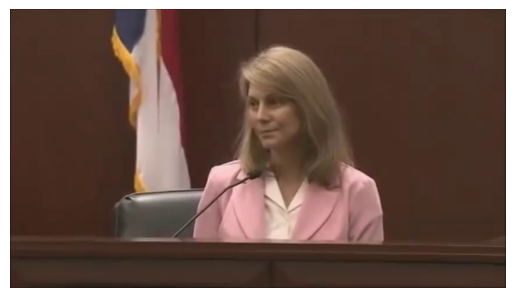

In [9]:
import matplotlib.pyplot as plt

sample_image_path = sample_frames[0]

image = cv2.imread(str(sample_image_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [10]:
import pandas as pd

df_results = pd.DataFrame(all_results)
df_results.to_csv(OUTPUT_DIR / "frame_extraction_log.csv", index=False)

df_results.head()

,video,status,original_fps,target_fps,total_frames,duration_seconds,saved_frames
0,trial_lie_001.mp4,success,29.97,5,510,17.017017,85
1,trial_lie_002.mp4,success,29.97,5,1874,62.529196,313
2,trial_lie_003.mp4,success,29.97,5,212,7.073740,36
3,trial_lie_004.mp4,success,29.97,5,349,11.644978,59
4,trial_lie_005.mp4,success,29.97,5,1602,53.453453,267
